# Fatigue regression

Canonical regression notebook for `fatigue_num` (0–5): **pure continuous regression**
(MAE / RMSE / R² vs integer labels; no rint, clip, or cutpoint search).
Same participant split and baselines as notebook 3; classification models
are in [`3 fatigue_modeling.ipynb`](3%20fatigue_modeling.ipynb) only.

Core logic lives in `src/modeling/`. Uses **20 daily physiological features**. Tree models one-hot encode `phase` to 23 columns.

**§3 tuned models (2):** `linear_regression`, `ordinal_rf`. ElasticNet, RBF SVR, and `catboost_regressor` were moved to [`unused models.ipynb`](unused%20models.ipynb) (ElasticNet/SVR collapsed to near-constant predictions under MAE tuning; CatBoost matched RF on test MAE).


In [57]:
%pip install -q -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
import sys
from pathlib import Path

_src = Path('../../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

# Ensure local src edits are picked up when re-running this cell.
for _mod in [k for k in list(sys.modules) if k == 'modeling' or k.startswith('modeling.')]:
    del sys.modules[_mod]

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from modeling.baselines import (
    run_all_baseline_benchmarks,
    summarize_baseline_metrics,
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from modeling.config import (
    DATA_PATH,
    FEATURE_COLUMNS,
    NUMERIC_FEATURES,
    N_CV_FOLDS,
    OPTUNA_TRIALS,
    TIME_COL,
    TIME_SERIES_GROUP_COLS,
)
from modeling.data import (
    build_split_bundle,
    load_fatigue_data,
    participant_strata,
    preprocess_after_split,
    split_participant_ids,
    split_summary_table,
)
from modeling.metrics import REGRESSION_METRIC_COLS, compute_regression_metrics
from modeling.registry import ORDINAL_MODELS
from modeling.runner import (
    print_all_models_feature_importance,
    print_and_plot_continuous_test_predictions,
    tune_and_benchmark_model,
    print_tune_summary,
)
from modeling.summaries import (
    CATEGORY_ORDER,
    collect_categorized_summaries,
)


## 1. Load data and split

Participants are held out with a **stratified split** on per-participant **mean fatigue** (`fatigue_num` averaged over each participant's days) so train/val and test have similar average fatigue levels.

“We randomly assign whole participants to train/val or test, but we do it in a way that both groups contain a similar mix of people with low, medium, and high average fatigue — not just a random 8 people who might all happen to be high-average-fatigue reporters.”

**Post-split preprocessing:** NaNs in `menstrual_health_literacy_num` and `daily_hrv` are filled with the **train/val median only** via `preprocess_after_split()` — test participants never contribute to that statistic.


In [59]:
df = load_fatigue_data('../../' + DATA_PATH)
df = df.sort_values(TIME_SERIES_GROUP_COLS + [TIME_COL]).reset_index(drop=True)

strata = participant_strata(df)
train_val_ids, test_ids = split_participant_ids(df['id'].unique(), strata=strata)
train_val_mask = df['id'].isin(train_val_ids)
test_mask = df['id'].isin(test_ids)

df = preprocess_after_split(df, train_val_mask)

bundle = build_split_bundle(df, train_val_ids, test_ids, train_val_mask, test_mask)

print(f"Rows: {len(df):,}  Participants: {df['id'].nunique()}")
display(split_summary_table(bundle))
print('Test participant ids:', sorted(bundle.test_ids))


Rows: 3,331  Participants: 42


,split,participants,rows,mean_fatigue
0,train_val,34,2659,2.462204
1,test,8,672,2.653274


Test participant ids: [np.int64(7), np.int64(14), np.int64(24), np.int64(38), np.int64(40), np.int64(41), np.int64(46), np.int64(50)]


Re-run the **init accumulators** cell below before a fresh partial run to clear prior tuned-model results.


In [60]:
# Re-run this cell to clear accumulated model results before a fresh partial run.
ordinal_results = []
ordinal_best_params = {}

## 2. Baseline benchmarks

Simple predictors evaluated with the same GroupKFold CV and held-out test protocol as the tuned models. Includes persistence baselines **`lag1_fatigue`** and **`expanding_mean`**.


In [61]:
ordinal_baseline_results = run_all_baseline_benchmarks(
    bundle,
    n_splits=N_CV_FOLDS,
    metrics_fn=compute_regression_metrics,
)

ordinal_baseline_summary = summarize_baseline_metrics(
    ordinal_baseline_results,
    metric_cols=REGRESSION_METRIC_COLS,
)

print('Regression baselines (test metrics: MAE / RMSE / R²)')
display(ordinal_baseline_summary[[c for c in ordinal_baseline_summary.columns if c.startswith('test_')]])


Regression baselines (test metrics: MAE / RMSE / R²)


,test_mae,test_rmse,test_r2
model,,,
global_mean,1.406250,1.640721,-0.188402
global_mode,1.156250,1.544479,-0.053072
lag1_fatigue,0.950893,1.424175,0.104593
expanding_mean,1.025298,1.336863,0.211017


MAE: Mean Absolute Error;

RMSE: Root Mean Squared Error, measures the variation in residual/error

R2: how much variability is explained by the model

QWK: Quadratic Weighted Kappa. QWK measures the agreement between two raters—such as an AI and a human—on an ordered scale. It is designed to adjust for chance agreements and heavily penalize larger scoring discrepancies over minor ones.

## 3. Train/Tune models

**Continuous regression** on `fatigue_num`: `predict()` returns continuous scores; metrics are MAE / RMSE / R² vs integer labels. Each model subsection runs **one code cell**:

1. **Optuna tune + benchmark** — `tune_and_benchmark_model` with participant `GroupKFold` CV.
2. Results are appended to `ordinal_results` and `ordinal_best_params` for §4–§7.


#### `linear_regression`

In [62]:
_name = 'linear_regression'
_result, _params = tune_and_benchmark_model(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_result)
ordinal_best_params[_name] = _params
print_tune_summary(_name, _result, _params)


[ok] linear_regression
  best_params: {'alpha': 9.668599030214608}
  cv_mae: 1.4715
  test_mae: 1.4152


#### `ordinal_rf`

Sole **tree** model in §3–§7 (linear + tree covers the main model-family contrast).

After Optuna **MAE** tuning on the same 20-feature split, test MAE was nearly identical to `catboost_regressor` (`ordinal_rf` ~1.316 vs CatBoost ~1.312). Keeping one tree avoids redundant reporting.

**Why keep RF:** uses sklearn `RandomForestRegressor` without an extra dependency.

**Why CatBoost was removed:** (moved to [`unused models.ipynb`](unused%20models.ipynb)). Its ablation also flagged almost every feature as important (only `lh_smooth` did not)—typical of boosting, where each tree chases residual error and can spread small gains across many predictors, so leave-one-out ablation overstates importance. Ridge and RF give sparser profiles that align better for §7 interpretation.


In [63]:
_name = 'ordinal_rf'
_result, _params = tune_and_benchmark_model(
    _name,
    bundle,
    ORDINAL_MODELS,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
)
ordinal_results.append(_result)
ordinal_best_params[_name] = _params
print_tune_summary(_name, _result, _params)


[ok] ordinal_rf
  best_params: {'n_estimators': 326, 'max_depth': 19, 'min_samples_leaf': 1}
  cv_mae: 1.3122
  test_mae: 1.3156


## 4. Results summary

Aggregates §2 baselines plus §3 tuned regression models. Results are grouped into **baseline** and **base** categories.

Metrics are **continuous MAE / RMSE / R²** (no QWK -- pure regression). The next cell prints **CV** tables then **test** tables (baseline → base), sorted by `cv_mae` or `test_mae` respectively. Hyperparameters are printed in §3 tune cells only (not repeated here).


In [64]:
# Merge baselines (§2) and base tuned models (§3).
# globals().get(...) allows partial notebook runs without NameError on skipped cells.

ordinal_results = globals().get('ordinal_results', [])
ordinal_best_params = globals().get('ordinal_best_params', {})

ran_tuned_models = sorted(ordinal_best_params)
print(f'Ran {len(ran_tuned_models)} tuned regression models: {ran_tuned_models}')

all_ordinal_results = ordinal_baseline_results + ordinal_results

category_summaries = collect_categorized_summaries(
    all_ordinal_results,
    include_best_params=False,
    metric_cols=REGRESSION_METRIC_COLS,
)

print('CV (sorted by cv_mae within each category; cv_* = mean over GroupKFold folds on train/val)')
for category in CATEGORY_ORDER:
    if category not in ('baseline', 'base'):
        continue
    cv_cat, _ = category_summaries[category]
    if cv_cat.empty:
        continue
    print(f'  {category}')
    display(cv_cat)

print('Test (sorted by test_mae within each category; refit on full train/val, scored on test participants)')
for category in CATEGORY_ORDER:
    if category not in ('baseline', 'base'):
        continue
    _, test_cat = category_summaries[category]
    if test_cat.empty:
        continue
    print(f'  {category}')
    display(test_cat)


Ran 2 tuned regression models: ['linear_regression', 'ordinal_rf']
CV (sorted by cv_mae within each category; cv_* = mean over GroupKFold folds on train/val)
  baseline


,cv_mae,cv_rmse,cv_r2,cv_mae_std
model,,,,
lag1_fatigue,0.824015,1.315205,0.096947,0.193110
expanding_mean,0.867974,1.198179,0.280799,0.127344
global_mode,1.216046,1.554387,-0.200378,0.243084
global_mean,1.348516,1.606173,-0.297646,0.153930


  base


,cv_mae,cv_rmse,cv_r2,cv_mae_std
model,,,,
ordinal_rf,1.312242,1.584664,-0.243538,0.197090
linear_regression,1.471498,1.694544,-0.473119,0.191107


Test (sorted by test_mae within each category; refit on full train/val, scored on test participants)
  baseline


,test_mae,test_rmse,test_r2
model,,,
lag1_fatigue,0.950893,1.424175,0.104593
expanding_mean,1.025298,1.336863,0.211017
global_mode,1.156250,1.544479,-0.053072
global_mean,1.406250,1.640721,-0.188402


  base


,test_mae,test_rmse,test_r2
model,,,
ordinal_rf,1.315570,1.584484,-0.108332
linear_regression,1.415174,1.677692,-0.242563


## 5. Continuous test-prediction verification

Refits each §3 model on train/val and predicts on **all held-out test rows**. Use this section to confirm `predict()` returns **continuous floats**, not rint/clipped integers.

**Output:** summary stats table + histogram/scatter plots per model (not every test-row prediction).

**Stats table:**

- **`n_unique_raw`** — How many **different prediction values** on the test set (each rounded to 6 decimals so float noise does not inflate the count).、
- **`frac_non_integer`** — Share of test predictions with a fractional part (`pred != round(pred)`); 0.0–1.0. Near **1.0** is expected; **0.0** triggers a collapse warning.

**Histograms:** dashed vertical lines mark integer fatigue levels 0–5; continuous models show mass **between** those ticks.

**Scatter:** integer `y_true` on x-axis vs continuous `pred` on y-axis; points off the integer grid on y confirm non-discrete predictions. `y_true` stays 0–5; models may predict outside that range.


[continuous verification] per-model prediction stats


,dtype,n_test,min,max,mean,std,n_unique_raw,frac_non_integer
model,,,,,,,,
linear_regression,float64,672,0.616379,3.467936,2.236827,0.530710,672,1.000000
ordinal_rf,float64,672,1.067724,3.799423,2.503287,0.585742,665,0.998512


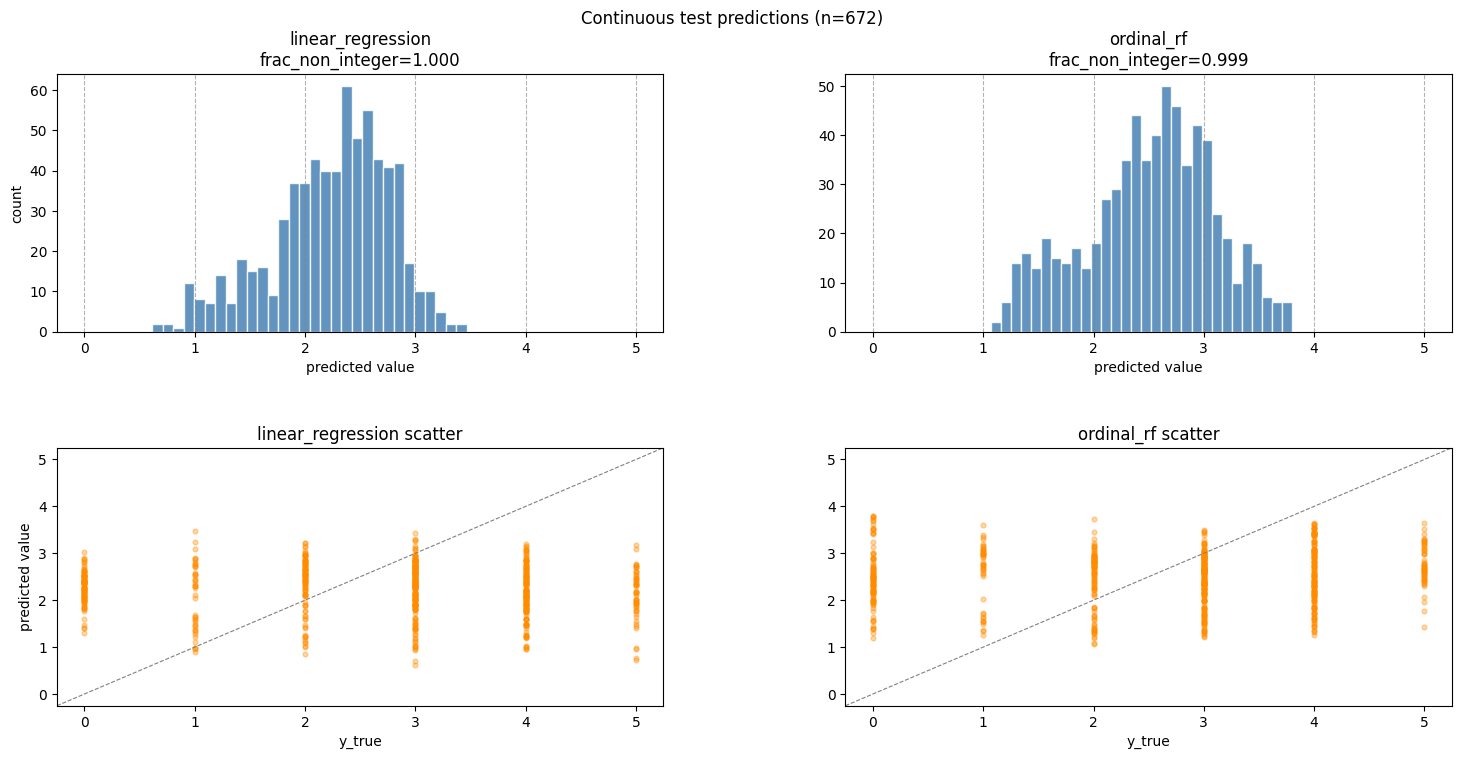

In [65]:
print_and_plot_continuous_test_predictions(
    bundle,
    ordinal_best_params,
    ORDINAL_MODELS,
    models=[
        "linear_regression",
        "ordinal_rf",
    ],
)


## 6. Feature correlation study

Multicollinearity screening on **all preprocessed rows** (train/val + test) after §1 `preprocess_after_split` — same pooled daily layout as §3 training.

1. **Pairwise Spearman rank** on **20** predictors (15 `NUMERIC_FEATURES` + `is_weekend` + 2 ordinal-coded columns + sexually-active value/missing via `_prepare_ridge_features`). Captures **monotonic** association; ordinal codes are included as ranks (no equal-spacing assumption).
2. **VIF** on the **Ridge design matrix** (same mixed encoding as §3 `linear_regression`): scaled `NUMERIC_FEATURES` + `is_weekend` + ordinal codes + sexually-active value/missing columns; **one-hot `phase` only** (`drop='first'` → 3 dummies; ~23 columns total).

**Excluded from Spearman matrix:** `phase` (nominal; one-hot in Ridge/VIF) and target `fatigue_num`. Raw sexually-active `-1` is not used as a rank level — missingness is `sexually_active_missing`.

**Features — Spearman matrix (20):**

| Group | Feature | Description |
|-------|---------|-------------|
| Activity | `lightly_activity` | Daily minutes, light activity tier |
| Activity | `moderately_activity` | Daily minutes, moderate activity tier |
| Activity | `very_activity` | Daily minutes, vigorous activity tier |
| Activity | `calories_sum` | Daily calories burned |
| HR zones | `cardio_zone` | Daily minutes in cardio heart-rate zone |
| HR zones | `fat_burn_zone` | Daily minutes in fat-burn zone |
| HR zones | `below_fat_burn_zone` | Daily minutes below fat-burn zone |
| Hormones | `lh_smooth` | LH, EWMA-smoothed (preprocess) |
| Hormones | `estrogen_smooth` | Estrogen, rolling median–centered smooth (preprocess) |
| Demographics | `filtered_demographic_vo2_max` | Participant VO2 max (interpolated within interval) |
| Demographics | `age_of_first_menarche` | Age at first menarche |
| Demographics | `age` | Participant age |
| Daily physiology | `daily_glucose` | Daily glucose |
| Daily physiology | `daily_hrv` | Daily HRV (train/val median imputation in §1) |
| Daily physiology | `sleep_score` | Daily sleep score |
| Ordinal (coded) | `exerciselevel_num` | Self-reported exercise level (ordered numeric code) |
| Ordinal (coded) | `menstrual_health_literacy_num` | Menstrual health literacy score (ordered code; train/val median imputation in §1) |
| Binary | `is_weekend` | Weekend indicator (0/1) |
| Sexually active | `sexually_active_num` | 0/1 when known (0 when missing, after prepare) |
| Sexually active | `sexually_active_missing` | 1 when original value was `-1` |

**Note:** Pooled daily rows (repeated measures per participant). Useful before §7 ablation; VIF complements pairwise ρ by checking redundancy **given all other Ridge columns**.


In [71]:
from modeling.models.ordinal import SEXUALLY_ACTIVE_MISSING_COL, _prepare_ridge_features

SPEARMAN_FEATURES = list(NUMERIC_FEATURES) + [
    "is_weekend",
    "exerciselevel_num",
    "menstrual_health_literacy_num",
    "sexually_active_num",
    SEXUALLY_ACTIVE_MISSING_COL,
]
assert len(SPEARMAN_FEATURES) == 20

spearman_df = _prepare_ridge_features(df[FEATURE_COLUMNS])
assert set(SPEARMAN_FEATURES).issubset(spearman_df.columns)
print(f"§6 Spearman features ({len(SPEARMAN_FEATURES)}):")
for i, name in enumerate(SPEARMAN_FEATURES, 1):
    print(f"  {i:2d}. {name}")


§6 Spearman features (20):
   1. lightly_activity
   2. moderately_activity
   3. very_activity
   4. calories_sum
   5. filtered_demographic_vo2_max
   6. cardio_zone
   7. fat_burn_zone
   8. below_fat_burn_zone
   9. lh_smooth
  10. estrogen_smooth
  11. age_of_first_menarche
  12. age
  13. daily_glucose
  14. daily_hrv
  15. sleep_score
  16. is_weekend
  17. exerciselevel_num
  18. menstrual_health_literacy_num
  19. sexually_active_num
  20. sexually_active_missing


### Pairwise correlation matrix

Spearman rank correlation on all **20** features above. Upper triangle masked; color centered at 0.


Pairwise Spearman correlation (20 features, n=3,331 rows)


,lightly_activity,moderately_activity,very_activity,calories_sum,filtered_demographic_vo2_max,cardio_zone,fat_burn_zone,below_fat_burn_zone,lh_smooth,estrogen_smooth,age_of_first_menarche,age,daily_glucose,daily_hrv,sleep_score,is_weekend,exerciselevel_num,menstrual_health_literacy_num,sexually_active_num,sexually_active_missing
lightly_activity,1.000,0.538,0.478,0.724,-0.073,0.261,0.476,-0.098,-0.015,0.004,-0.070,-0.214,-0.024,0.023,-0.107,0.031,0.240,-0.007,-0.114,-0.026
moderately_activity,0.538,1.000,0.868,0.707,0.036,0.498,0.511,-0.250,0.053,-0.076,0.036,-0.107,-0.065,0.031,-0.058,-0.019,0.332,-0.109,-0.112,0.038
very_activity,0.478,0.868,1.000,0.698,0.025,0.584,0.414,-0.189,0.046,-0.076,0.057,-0.107,-0.046,0.047,-0.074,-0.050,0.322,-0.098,-0.081,0.054
calories_sum,0.724,0.707,0.698,1.000,-0.139,0.501,0.615,-0.212,0.040,-0.052,0.029,-0.205,-0.036,-0.018,-0.145,0.004,0.371,-0.023,-0.077,-0.025
filtered_demographic_vo2_max,-0.073,0.036,0.025,-0.139,1.000,-0.072,-0.228,0.191,0.219,-0.028,-0.016,-0.133,-0.064,0.268,-0.017,-0.009,-0.067,-0.120,0.149,-0.195
cardio_zone,0.261,0.498,0.584,0.501,-0.072,1.000,0.497,-0.343,0.040,0.042,0.029,-0.086,-0.072,-0.006,-0.093,-0.042,0.341,-0.064,-0.137,0.035
fat_burn_zone,0.476,0.511,0.414,0.615,-0.228,0.497,1.000,-0.541,0.013,0.081,-0.010,-0.081,-0.081,-0.212,-0.089,0.015,0.349,-0.094,-0.215,0.104
below_fat_burn_zone,-0.098,-0.250,-0.189,-0.212,0.191,-0.343,-0.541,1.000,-0.050,-0.074,-0.006,0.064,0.111,0.113,0.069,-0.045,-0.286,0.076,0.149,-0.070
lh_smooth,-0.015,0.053,0.046,0.040,0.219,0.040,0.013,-0.050,1.000,0.190,0.039,-0.029,-0.019,-0.045,0.039,0.012,0.049,-0.186,0.011,-0.044
estrogen_smooth,0.004,-0.076,-0.076,-0.052,-0.028,0.042,0.081,-0.074,0.190,1.000,-0.086,-0.083,0.049,0.061,-0.008,0.005,0.024,0.138,-0.018,-0.048


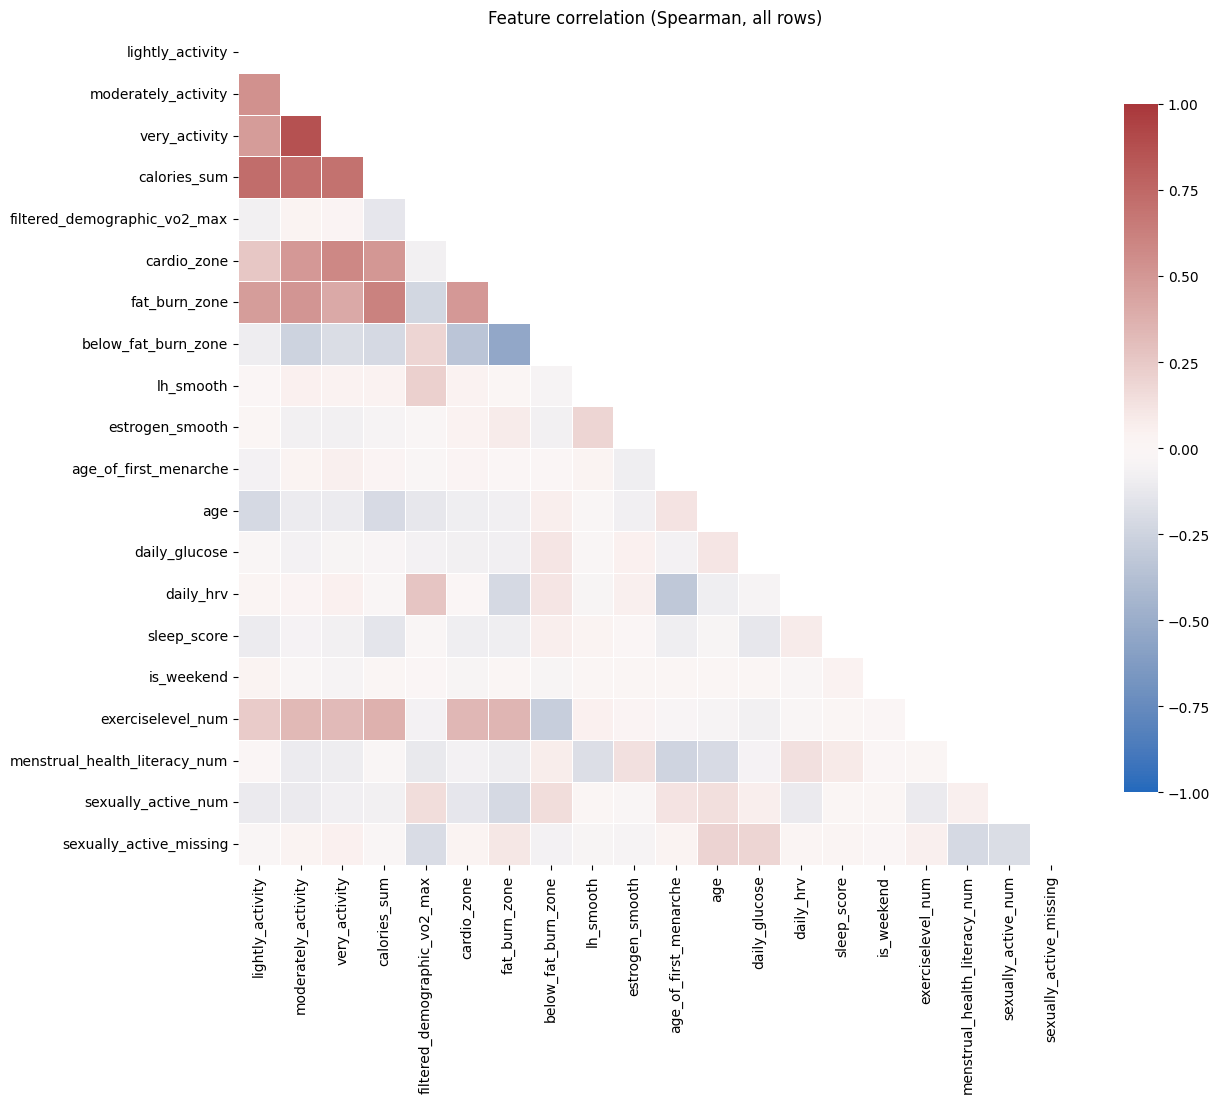

In [72]:
corr_df = spearman_df[SPEARMAN_FEATURES]
corr = corr_df.corr(method="spearman")

print(f"Pairwise Spearman correlation ({len(SPEARMAN_FEATURES)} features, n={len(corr_df):,} rows)")
display(corr.round(3))

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Feature correlation (Spearman, all rows)")
plt.tight_layout()
plt.show()


### Variance inflation factors (Ridge design matrix)

VIF measures how much the variance of a **linear** coefficient would inflate because that column is redundant with the others. Values **> 5** (or **> 10**) often flag problematic multicollinearity.

Uses the **same preprocessing as §3 Ridge** (`_prepare_ridge_features` + `_ridge_preprocessor` in `modeling.models.ordinal`):

- **Scaled:** 15 `NUMERIC_FEATURES` + `is_weekend` + `exerciselevel_num` + `menstrual_health_literacy_num` + `sexually_active_num` (0/1 when known) + derived `sexually_active_missing` (1 when original value was `-1`).
- **One-hot:** `phase` only (`drop='first'`).

Input: `df[FEATURE_COLUMNS]` (20 logical columns → ~23 transformed columns). The `-1` sexually-active sentinel is **not** a third category; missingness is its own column.


In [73]:
from modeling.models.ordinal import _prepare_ridge_features, _ridge_preprocessor

X_prepared = _prepare_ridge_features(df[FEATURE_COLUMNS])
prep = _ridge_preprocessor()
X_design = prep.fit_transform(X_prepared)
col_names = prep.get_feature_names_out()
X_vif = add_constant(X_design, has_constant="add")

vif_rows = []
for j, name in enumerate(col_names):
    vif = variance_inflation_factor(X_vif, j + 1)
    vif_rows.append({"feature": name, "vif": vif})

vif_df = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
display(vif_df.assign(vif=lambda s: s["vif"].replace([np.inf], np.nan)).round(2))

high = vif_df[np.isfinite(vif_df["vif"]) & (vif_df["vif"] > 5)]
print(f"Columns with finite VIF > 5: {len(high)}")
num_vif = vif_df[vif_df["feature"].str.startswith("num__") & np.isfinite(vif_df["vif"])]
if not num_vif.empty:
    top = num_vif.loc[num_vif["vif"].idxmax()]
    print(f"Max finite VIF among scaled columns (num__*): {top['feature']} = {top['vif']:.2f}")
phase_vif = vif_df[
    vif_df["feature"].str.startswith("cat__phase_") & np.isfinite(vif_df["vif"])
]
if not phase_vif.empty:
    top_phase = phase_vif.loc[phase_vif["vif"].idxmax()]
    print(
        f"Max finite VIF among phase dummies: {top_phase['feature']} = {top_phase['vif']:.2f}"
    )


,feature,vif
2,num__very_activity,5.46
1,num__moderately_activity,5.17
3,num__calories_sum,2.94
6,num__fat_burn_zone,2.50
5,num__cardio_zone,1.92
21,cat__phase_Luteal,1.92
20,cat__phase_Follicular,1.90
22,cat__phase_Menstrual,1.81
4,num__filtered_demographic_vo2_max,1.54
0,num__lightly_activity,1.45


Columns with finite VIF > 5: 2
Max finite VIF among scaled columns (num__*): num__very_activity = 5.46
Max finite VIF among phase dummies: cat__phase_Luteal = 1.92


## 7. Feature importance (linear regression + RF)

Requires §1 and all §3 tuning cells. For each tuned model, runs **leave-one-out GroupKFold ablation** on the **20 features** (drop one logical feature, retrain, no hyperparameter tuning, compare CV MAE), then a **cross-model consensus** table with side-by-side `cv_mae_increase_vs_all` per model (sorted by random forest, then linear regression).

**`cv_mae_increase_vs_all > 0`** means removing that feature **hurts** CV MAE — it is more necessary for prediction (given the other features). Larger values rank higher in the per-model ablation tables.


`linear_regression` uses `bundle.X_train_val` (20 base columns); tree models use `bundle.X_train_val_tree` (phase one-hot). Ablation drops all columns for one logical base feature (e.g. all `phase_*` when ablating `phase`) so CV ablation is the fairest cross-model comparison. Tables show **CV MAE increase** when a feature is removed (`cv_mae_increase_vs_all`), not absolute MAE without that feature.

The cross-model consensus table has columns: `feature`, `ordinal_rf_cv_mae_increase_vs_all`, `linear_regression_cv_mae_increase_vs_all`, sorted descending by RF then Ridge. A supplementary **top-5 overlap** bullet list still prints below.


In [77]:
print_all_models_feature_importance(
    bundle,
    ordinal_best_params,
    ORDINAL_MODELS,
    models=[
        "linear_regression",
        "ordinal_rf",
    ],
)



linear_regression — ablation (all-20-feature CV MAE: 1.4715)


,feature,cv_mae_increase_vs_all
0,sleep_score,0.020412
1,fat_burn_zone,0.017236
2,moderately_activity,0.011895
3,very_activity,0.011426
4,exerciselevel_num,0.005724
5,menstrual_health_literacy_num,0.004905
6,cardio_zone,0.002267
7,is_weekend,0.000287
8,below_fat_burn_zone,-0.001342
9,phase,-0.003260



ordinal_rf — ablation (all-20-feature CV MAE: 1.3122)


,feature,cv_mae_increase_vs_all
0,filtered_demographic_vo2_max,0.026386
1,age_of_first_menarche,0.016635
2,lightly_activity,0.007041
3,moderately_activity,0.004489
4,very_activity,0.004432
5,lh_smooth,0.003708
6,sleep_score,0.002427
7,sexually_active_num,0.002232
8,daily_hrv,0.002092
9,cardio_zone,0.001331



Cross-model consensus (cv_mae_increase_vs_all)


,feature,ordinal_rf_cv_mae_increase_vs_all,linear_regression_cv_mae_increase_vs_all
0,filtered_demographic_vo2_max,0.0264,-0.0409
1,age_of_first_menarche,0.0166,-0.0764
2,lightly_activity,0.0070,-0.0060
3,moderately_activity,0.0045,0.0119
4,very_activity,0.0044,0.0114
5,lh_smooth,0.0037,-0.0035
6,sleep_score,0.0024,0.0204
7,sexually_active_num,0.0022,-0.0791
8,daily_hrv,0.0021,-0.0314
9,cardio_zone,0.0013,0.0023


Ablation (top-5 overlap):
  In top-5 for 2 model(s):
    moderately_activity: linear_regression (#3), ordinal_rf (#4)
    very_activity: linear_regression (#4), ordinal_rf (#5)
  In top-5 for 1 model(s):
    age_of_first_menarche: ordinal_rf (#2)
    exerciselevel_num: linear_regression (#5)
    fat_burn_zone: linear_regression (#2)
    filtered_demographic_vo2_max: ordinal_rf (#1)
    lightly_activity: ordinal_rf (#3)
    sleep_score: linear_regression (#1)
